# Simulation of correlations for linear models 

In [24]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, ElasticNetCV, ElasticNet

plt.style.use('ggplot')

In [ ]:
N = 30
T = 20000
rho = 0.05

def run_sim(model, n=200, N=N, T=T, T_OOS=T, rho=rho, oos=True):
    res = 0
    for k in tqdm(range(n)):
        
        # constant rho_i case
        rho_i = np.array([rho * np.sqrt(1 / N) for k in range(N)])

        # Not sure this commented code is correct.
        # random rho_i re-normalized
        # rho_i = np.random.uniform(low=-1, high=1, size=N)
        # rho_i = np.random.normal(size=N)
        # norm_factor = np.sum([rho_i[k]**2 for k in range(N)])
        # rho_i = np.sqrt(np.abs(rho_i / norm_factor)) * np.sign(rho_i)
        # rho_i = np.sqrt((rho_i**2) * (rho**2)) * np.sign(rho_i)


        mean = np.zeros(N)
        cov = np.eye(N)
        X = np.random.multivariate_normal(mean=mean, cov=cov, size=T)
        X_OOS = np.random.multivariate_normal(mean=mean, cov=cov, size=T_OOS)
        eps = np.random.normal(size=T)

        y_tilde = np.dot(X, rho_i)
        y_tilde_OOS = np.dot(X_OOS, rho_i)

        y = y_tilde + np.sqrt(1-rho**2)*eps

        model.fit(X, y)
        if oos:
            res += np.corrcoef(model.predict(X_OOS), y_tilde_OOS)[0][1]
        else:
            res += np.corrcoef(model.predict(X), y_tilde)[0][1]
    return res / n

## All models (OOS)

In [26]:
N_list = [10, 20, 30, 50, 100]
ols_theo = []
ols_sim = []
lasso_sim = []
ridge_sim = []
ratios = []
for N in N_list:
    ratio = N/T
    ratios.append(ratio)
    ols_theo.append(rho / np.sqrt(rho**2 + (1-rho**2) * ratio /(1 -ratio)))
    ols_sim.append(run_sim(LinearRegression(), N=N))
    lasso_sim.append(run_sim(ElasticNetCV(l1_ratio=1, alphas=np.linspace(1e-6, 1e-2, num=50), cv=3), N=N))
    ridge_sim.append(run_sim(ElasticNetCV(l1_ratio=0.001, alphas=np.linspace(1e-6, 1e-2, num=50), cv=3), N=N))

100%|██████████| 200/200 [00:25<00:00,  7.86it/s]


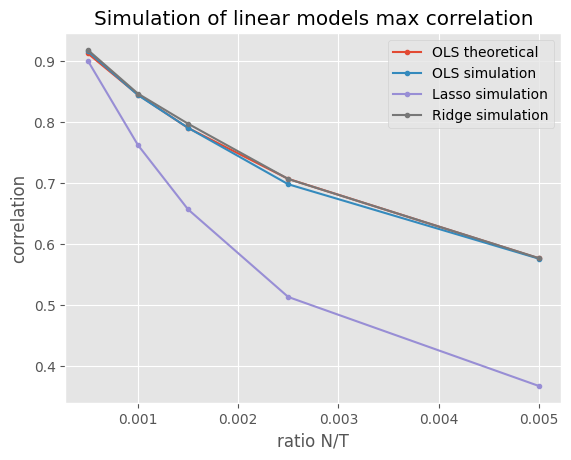

In [27]:
plt.plot(ratios, ols_theo, label='OLS theoretical', marker='.')
plt.plot(ratios, ols_sim, label='OLS simulation', marker='.')
plt.plot(ratios, lasso_sim, label='Lasso simulation', marker='.')
plt.plot(ratios, ridge_sim, label='Ridge simulation', marker='.')
plt.ylabel('correlation')
plt.xlabel('ratio N/T')
plt.legend()
plt.title('Simulation of linear models max correlation');

## OLS only

In [21]:
T = 1000
rho = 0.2

In [22]:
N_list = [10, 20, 50, 100, 200, 500]
ols_is_theo = []
ols_oos_theo = []
ols_is_sim = []
ols_oos_sim = []
ratios = []
for N in N_list:
    ratio = N/T
    ratios.append(ratio)
    ols_is_theo.append(rho / np.sqrt(rho**2 + (1-rho**2) * ratio))
    ols_oos_theo.append(rho / np.sqrt(rho**2 + (1-rho**2) * ratio/(1-ratio)))
    ols_is_sim.append(run_sim(LinearRegression(), T=T, N=N, rho=rho, n=200, oos=False))
    ols_oos_sim.append(run_sim(LinearRegression(), T=T, N=N, rho=rho, n=200, oos=True))

100%|██████████| 200/200 [01:03<00:00,  3.14it/s]


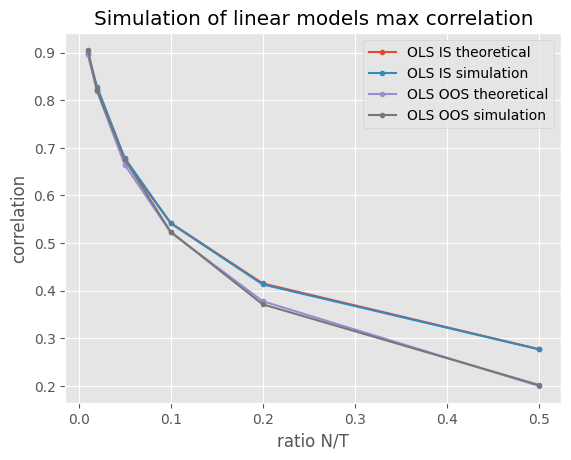

In [23]:
plt.plot(ratios, ols_is_theo, label='OLS IS theoretical', marker='.')
plt.plot(ratios, ols_is_sim, label='OLS IS simulation', marker='.')
plt.plot(ratios, ols_oos_theo, label='OLS OOS theoretical', marker='.')
plt.plot(ratios, ols_oos_sim, label='OLS OOS simulation', marker='.')
plt.ylabel('correlation')
plt.xlabel('ratio N/T')
plt.legend()
plt.title('Simulation of linear models max correlation');